# Klasifikasi Tipe Akomodasi AirBnB Berdasarkan Karakteristik Listing Menggunakan CNN

# Import Library

In [1]:
pip install streamlit

  Using cached streamlit-1.58.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached altair-6.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached pyarrow-24.0.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.2.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached uvicorn-0.48.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached httptools-0.8.0-cp313-cp313-win_amd64.whl.metadata (3.7 kB)
  Using cached python_multipart-0.0.29-py3-none-any.whl.metadata (2.1 kB)
  Using cached websockets-16.0-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import streamlit as st
import joblib

import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

# Load Dataset

In [4]:
import os

local_csv = 'new_york_listings_2024.csv'
if os.path.exists(local_csv):
    df = pd.read_csv(local_csv, low_memory=False)
    print(f"[INFO] Dataset loaded from local file: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    raise FileNotFoundError(
        "Dataset 'new_york_listings_2024.csv' tidak ditemukan di folder project. "
        "Silakan letakkan file CSV di folder project (F:\\Klasifikasi tipe akomodasi) atau ubah nama/jalur file sesuai lokasi Anda."
    )

[INFO] Dataset loaded from local file: 20758 rows, 22 columns


# Filter Kelas

In [5]:
valid_classes = ['Entire home/apt', 'Private room', 'Shared room']
df = df[df['room_type'].isin(valid_classes)]
print(f"Setelah filter kelas: {df.shape}")

Setelah filter kelas: (20646, 22)


# Hapus Duplikat

In [6]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Duplikat dihapus: {initial_rows - len(df)} rows")
print(f"Setelah hapus duplikat: {df.shape}")

Duplikat dihapus: 0 rows
Setelah hapus duplikat: (20646, 22)


# Hapus Kolom yang tidak dipakai

In [7]:
columns_to_drop = [
    'id', 'NAME', 'host id', 'host name', 'last review',
    'house_rules', 'license', 'country', 'country code',
    'Construction year', 'review rate number'
]
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)
print(f"Kolom setelah cleaning: {list(df.columns)}")

Kolom setelah cleaning: ['name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'rating', 'bedrooms', 'beds', 'baths']


# Cleaning Kolom Price

In [8]:
df['price'] = df['price'].astype(str).str.replace(',', '', regex=False)
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(' ', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Handling Missing Value

In [9]:
print("\n" + "="*70)
print("MISSING VALUE SEBELUM IMPUTASI:")
print(df.isnull().sum())

# Numeric columns - SESUAIKAN DENGAN NAMA KOLOM YANG ADA
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews',
                'reviews_per_month', 'calculated_host_listings_count',
                'availability_365', 'latitude', 'longitude', 'rating', 'bedrooms', 'beds', 'baths']  # Perbaiki nama kolom dan tambahkan rating

# Perbaiki kolom numeric dengan median
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

categorical_cols = ['neighbourhood_group', 'neighbourhood']

for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna('Unknown')

print("\nMISSING VALUE SETELAH IMPUTASI:")
print(df.isnull().sum())


MISSING VALUE SEBELUM IMPUTASI:
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

MISSING VALUE SETELAH IMPUTASI:
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude             

# Perbaiki kolom neighbourhood

In [10]:
if 'neighbourhood group' in df.columns:
    df['neighbourhood group'] = df['neighbourhood group'].replace({
        'manhatan': 'Manhattan',
        'brookln': 'Brooklyn'
    })

# Encoding Fitur Kategorikal

In [11]:
X = df.drop('room_type', axis=1)
y = df['room_type']

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Encoding untuk fitur kategorikal
categorical_features = ['neighbourhood_group', 'neighbourhood',
                        'host_identity_verified', 'instant_bookable',
                        'cancellation_policy']

# Filter yang ada
categorical_features = [col for col in categorical_features if col in X.columns]

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)
print(f"Jumlah fitur setelah one-hot encoding: {X_encoded.shape[1]}")

Jumlah fitur setelah one-hot encoding: 243


# Normalisasi

In [12]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['price', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'calculated_host_listings_count',
                    'availability_365', 'latitude', 'longitude', 'rating', 'bedrooms', 'beds', 'baths']

numeric_features = [col for col in numeric_features if col in X_encoded.columns]

scaler = StandardScaler()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])
print(f"Fitur numerik dinormalisasi: {numeric_features}")

Fitur numerik dinormalisasi: ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude', 'rating', 'bedrooms', 'beds', 'baths']


# Feature Selection

In [13]:
print("\n" + "="*70)
print("FEATURE SELECTION")

# Fitur numerik yang tersedia di dataset baru
selected_numeric = ['price', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'availability_365',
                    'calculated_host_listings_count', 'latitude', 'longitude',
                    'number_of_reviews_ltm', 'rating', 'bedrooms', 'beds', 'baths']

# Filter yang ada
selected_numeric = [col for col in selected_numeric if col in X_encoded.columns]

# Pilih kolom neighbourhood group
group_columns = [col for col in X_encoded.columns if col.startswith('neighbourhood_group_')]

# Pilih kolom neighbourhood (top 20)
neighbourhood_cols = [col for col in X_encoded.columns if col.startswith('neighbourhood_')]
top_neighbourhoods = df['neighbourhood'].value_counts().head(20).index.tolist()
selected_neighbourhood = [f'neighbourhood_{n}' for n in top_neighbourhoods
                          if f'neighbourhood_{n}' in X_encoded.columns]

# Gabungkan fitur
selected_columns = selected_numeric + group_columns + selected_neighbourhood
X_selected = X_encoded[selected_columns].astype(np.float32)

print(f"TOTAL FITUR TERPILIH: {len(selected_columns)} fitur")
print(f" - Numerik: {len(selected_numeric)}")
print(f" - Neighbourhood Group: {len(group_columns)}")
print(f" - Neighbourhood (top 20): {len(selected_neighbourhood)}")


FEATURE SELECTION
TOTAL FITUR TERPILIH: 38 fitur
 - Numerik: 13
 - Neighbourhood Group: 5
 - Neighbourhood (top 20): 20


# Split Data

In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# One-hot encode the target variable
y_onehot = to_categorical(y_encoded, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Stratify using the original encoded labels
)

print(f"\nData Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Data Testing:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)\n")
print("\nDistribusi kelas pada training set:")
for i, kelas in enumerate(label_encoder.classes_):
    count = np.sum(np.argmax(y_train, axis=1) == i)
    print(f"  {kelas}: {count} ({count/len(y_train)*100:.1f}%)")


Data Training: 16516 samples (80%)
Data Testing:  4130 samples (20%)


Distribusi kelas pada training set:
  Entire home/apt: 9239 (55.9%)
  Private room: 7043 (42.6%)
  Shared room: 234 (1.4%)


### Oversampling dengan SMOTE

In [15]:
# Konversi y_train dari one-hot kembali ke label untuk SMOTE
y_train_labels = np.argmax(y_train, axis=1)

print(f"Distribusi kelas sebelum SMOTE: {Counter(y_train_labels)}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train_labels)

print(f"Distribusi kelas setelah SMOTE: {Counter(y_train_res)}")

# Konversi y_train_res kembali ke one-hot encoding
y_train_res_onehot = to_categorical(y_train_res, num_classes=3)

# Update X_train dan y_train
X_train = X_train_res
y_train = y_train_res_onehot

print(f"\nShape X_train setelah SMOTE: {X_train.shape}")
print(f"Shape y_train setelah SMOTE: {y_train.shape}")

Distribusi kelas sebelum SMOTE: Counter({np.int64(0): 9239, np.int64(1): 7043, np.int64(2): 234})
Distribusi kelas setelah SMOTE: Counter({np.int64(0): 9239, np.int64(1): 9239, np.int64(2): 9239})

Shape X_train setelah SMOTE: (27717, 38)
Shape y_train setelah SMOTE: (27717, 3)


### Reshape Data untuk CNN

In [16]:
# Reshape data untuk input Conv1D (batch_size, timesteps, features)
# Dalam kasus ini, setiap fitur adalah satu 'timestep'
# Maka kita reshape dari (samples, features) menjadi (samples, features, 1)
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Shape X_train setelah reshape: {X_train.shape}")
print(f"Shape X_test setelah reshape: {X_test.shape}")

Shape X_train setelah reshape: (27717, 38, 1)
Shape X_test setelah reshape: (4130, 38, 1)


# Model CNN

In [17]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input

# Model definition for a 1D CNN
model = Sequential([
    Input(shape=(X_train.shape[1], 1)), # Input layer (features, 1)

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(), # Use GlobalAveragePooling1D to flatten for Dense layers

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax') # Output layer
])

# Kompilasi Model

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3797 - loss: 1.3254 - val_accuracy: 0.6075 - val_loss: 0.9924 - learning_rate: 5.0000e-04
Epoch 2/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4430 - loss: 1.1088 - val_accuracy: 0.6748 - val_loss: 0.7933 - learning_rate: 5.0000e-04
Epoch 3/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5000 - loss: 1.0127 - val_accuracy: 0.6896 - val_loss: 0.6761 - learning_rate: 5.0000e-04
Epoch 4/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5712 - loss: 0.9137 - val_accuracy: 0.7114 - val_loss: 0.6406 - learning_rate: 5.0000e-04
Epoch 5/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6202 - loss: 0.8380 - val_accuracy: 0.7266 - val_loss: 0.6124 - learning_rate: 5.0000e-04
Epoch 6/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6473 - loss: 0.7907 - val_accuracy: 0.7462 - val_loss: 0.5803 - learning_rate: 5.0000e-04
Epoch 7/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - acc

# Evaluasi Model

In [20]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
print(f"\nAkurasi Model: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Akurasi Model: 78.23%

Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.79      0.85      0.82      2310
   Private room       0.77      0.71      0.74      1761
    Shared room       0.82      0.15      0.26        59

       accuracy                           0.78      4130
      macro avg       0.79      0.57      0.61      4130
   weighted avg       0.78      0.78      0.78      4130


Confusion Matrix:
[[1966  344    0]
 [ 503 1256    2]
 [  18   32    9]]


# Visualisasi Akhir

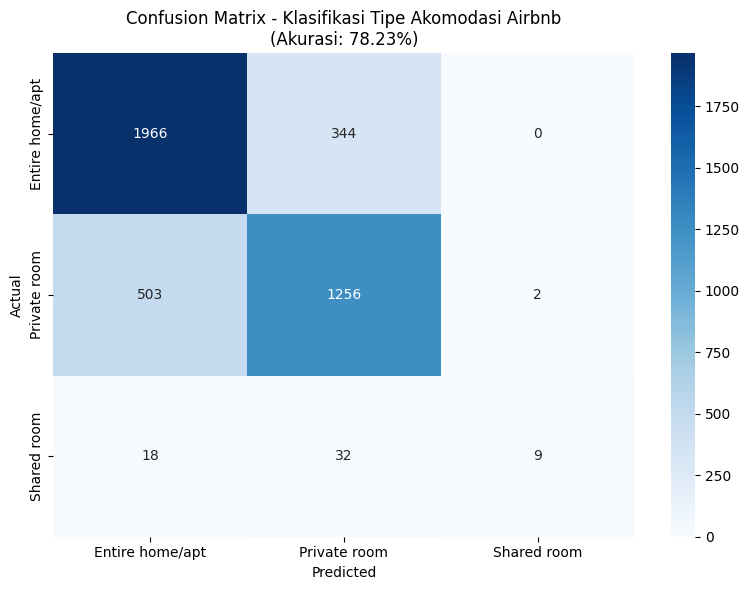

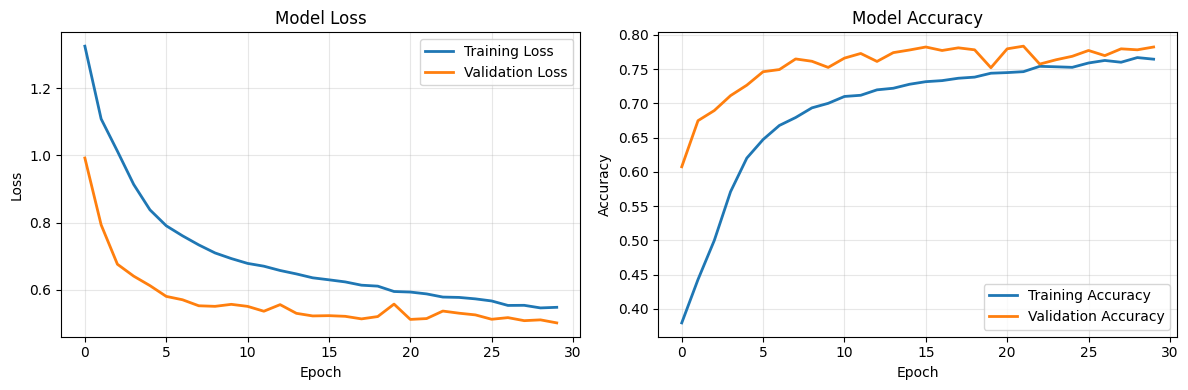

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - Klasifikasi Tipe Akomodasi Airbnb\n(Akurasi: {accuracy*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Training History Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

# Simpan Model

In [22]:
import joblib

# Simpan model dan preprocessor
model.save('cnn_airbnb_model.h5')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder_cnn.pkl')
joblib.dump(X_encoded.columns.tolist(), 'feature_columns.pkl')

print("Model dan preprocessor disimpan!")

Model dan preprocessor disimpan!


# Fungsi Klasifikasi

In [23]:
def klasifikasi_akomodasi(listing_baru):
    """
    INPUT: Data listing baru (dictionary)
    OUTPUT: Hasil klasifikasi tipe akomodasi
    """

    # Load model dan preprocessor
    try:
        model
    except NameError:
        model = tf.keras.models.load_model('cnn_airbnb_model.h5')
        scaler = joblib.load('scaler.pkl')
        label_encoder = joblib.load('label_encoder_cnn.pkl')
        feature_columns = joblib.load('feature_columns.pkl')

    # Konversi ke DataFrame
    input_df = pd.DataFrame([listing_baru])

    # One-hot encoding
    input_encoded = pd.get_dummies(input_df, columns=['neighbourhood group', 'neighbourhood'])

    # Tambahkan kolom yang hilang
    for col in feature_columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0

    # Urutkan kolom sesuai training
    input_encoded = input_encoded[feature_columns]

    # Normalisasi
    cols_to_scale = [col for col in numeric_features if col in input_encoded.columns]
    if cols_to_scale:
        df_for_scaling = input_encoded[cols_to_scale].copy()
        scaled_data = scaler.transform(df_for_scaling)
        input_encoded[cols_to_scale] = scaled_data

    # Reshape untuk CNN
    X_input = input_encoded.values.astype(np.float32)
    X_input = X_input.reshape(X_input.shape[0], X_input.shape[1], 1)

    # Klasifikasi
    pred_proba = model.predict(X_input, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    pred_label = label_encoder.inverse_transform([pred_class])[0]
    confidence = pred_proba[pred_class] * 100

    print("\n" + "="*70)
    print("OUTPUT: HASIL KLASIFIKASI CNN")
    print("="*70)
    print(f"\n  TIPE AKOMODASI: {pred_label.upper()}")
    print(f"  TINGKAT KEPERCAYAAN: {confidence:.2f}%")

    print("\n  PROBABILITAS PER KELAS:")
    for i, kelas in enumerate(label_encoder.classes_):
        bar = "█" * int(pred_proba[i] * 30)
        print(f"    {kelas:20s}: {pred_proba[i]*100:5.2f}% {bar}")

    print("\n" + "="*70)
    print("KESIMPULAN")
    print("="*70)

    if confidence > 80:
        print(f"\n KLASIFIKASI SANGAT YAKIN (kepercayaan >80%)")
    elif confidence > 60:
        print(f"\n KLASIFIKASI CUKUP YAKIN (kepercayaan 60-80%)")
    else:
        print(f"\n KLASIFIKASI KURANG YAKIN (kepercayaan <60%)")

    return {
        'tipe_akomodasi': pred_label,
        'kepercayaan': confidence,
        'probabilitas': {label_encoder.classes_[i]: pred_proba[i] for i in range(3)}
    }

# Output Akhir

In [ ]:
## STREAMLIT INTERFACE
#def klasifikasi_akomodasi_streamlit(listing_baru):
#    """
#    INPUT: Data listing baru (dictionary)
#    OUTPUT: Hasil klasifikasi tipe akomodasi (Streamlit version)
#    """
#    # Load model dan preprocessor
#    try:
#        model
#    except NameError:
#        model = tf.keras.models.load_model('cnn_airbnb_model.h5')
#        scaler = joblib.load('scaler.pkl')
#        label_encoder = joblib.load('label_encoder_cnn.pkl')
#        feature_columns = joblib.load('feature_columns.pkl')
#
#    # Konversi ke DataFrame
#    input_df = pd.DataFrame([listing_baru])
#
#    # One-hot encoding
#    input_encoded = pd.get_dummies(input_df, columns=['neighbourhood group', 'neighbourhood'])
#
#    # Tambahkan kolom yang hilang
#    for col in feature_columns:
#        if col not in input_encoded.columns:
#            input_encoded[col] = 0
#
#    # Urutkan kolom sesuai training
#    input_encoded = input_encoded[feature_columns]
#
#    # Normalisasi
#    cols_to_scale = [col for col in numeric_features if col in input_encoded.columns]
#    if cols_to_scale:
#        df_for_scaling = input_encoded[cols_to_scale].copy()
#        scaled_data = scaler.transform(df_for_scaling)
#        input_encoded[cols_to_scale] = scaled_data
#
#    # Reshape untuk CNN
#    X_input = input_encoded.values.astype(np.float32)
#    X_input = X_input.reshape(X_input.shape[0], X_input.shape[1], 1)
#
#    # Klasifikasi
#    pred_proba = model.predict(X_input, verbose=0)[0]
#    pred_class = np.argmax(pred_proba)
#    pred_label = label_encoder.inverse_transform([pred_class])[0]
#    confidence = pred_proba[pred_class] * 100
#
#    return {
#        'tipe_akomodasi': pred_label,
#        'kepercayaan': confidence,
#        'probabilitas': {label_encoder.classes_[i]: float(pred_proba[i]) for i in range(3)}
#    }
#
## Setup Streamlit
#st.set_page_config(page_title="Klasifikasi Akomodasi AirBnB", page_icon="🏠", layout="wide")
#st.title("🏠 Sistem Klasifikasi Tipe Akomodasi AirBnB")
#st.markdown("Menggunakan CNN untuk memprediksi tipe akomodasi berdasarkan karakteristik listing")
#
## Sidebar untuk input
#with st.sidebar:
#    st.header("📋 Input Data Listing")
#    
#    # Ambil daftar group yang valid dari dataset
#    valid_groups = sorted(df['neighbourhood group'].dropna().unique().tolist())
#    selected_group = st.selectbox(
#        "Pilih Neighbourhood Group:",
#        valid_groups,
#        key="group_select"
#    )
#    
#    # Ambil daftar neighbourhood berdasarkan group yang dipilih
#    valid_hoods = sorted(
#        df[df['neighbourhood group'] == selected_group]['neighbourhood'].dropna().unique().tolist()
#    )
#    selected_hood = st.selectbox(
#        "Pilih Neighbourhood:",
#        valid_hoods,
#        key="hood_select"
#    )
#    
#    # Input harga
#    harga = st.number_input(
#        "Harga per malam (USD):",
#        min_value=10.0,
#        max_value=500.0,
#        value=100.0,
#        step=10.0
#    )
#    
#    # Input minimum nights
#    min_nights = st.number_input(
#        "Minimum malam menginap:",
#        min_value=1,
#        max_value=365,
#        value=30,
#        step=1
#    )
#    
#    st.divider()
#    
#    # Tombol klasifikasi
#    submit_btn = st.button(
#        "🔍 Lakukan Klasifikasi",
#        key="submit_btn",
#        use_container_width=True,
#        type="primary"
#    )
#
## Main content area
#col1, col2 = st.columns([1, 1])
#
#with col1:
#    st.subheader("📊 Informasi Dataset")
#    groups = df['neighbourhood group'].dropna().unique()
#    for group in sorted(groups):
#        count = len(df[df['neighbourhood group'] == group])
#        st.metric(f"{group}", f"{count} listing")
#
#with col2:
#    st.subheader("✏️ Ringkasan Input")
#    if 'listing_data' in st.session_state:
#        st.info(
#            f"**Neighbourhood Group:** {st.session_state.listing_data['neighbourhood group']}\n\n"
#            f"**Neighbourhood:** {st.session_state.listing_data['neighbourhood']}\n\n"
#            f"**Harga:** ${st.session_state.listing_data['price']:,.0f}\n\n"
#            f"**Minimum Malam:** {st.session_state.listing_data['minimum nights']}"
#        )
#    else:
#        st.info("Isi form di sidebar dan klik 'Lakukan Klasifikasi'")
#
## Proses klasifikasi saat tombol ditekan
#if submit_btn:
#    listing_user = {
#        'neighbourhood group': selected_group,
#        'neighbourhood': selected_hood,
#        'price': harga,
#        'minimum nights': min_nights,
#        'number of reviews': 30,
#        'reviews per month': 0.5,
#        'availability 365': 200,
#        'calculated host listings count': 1,
#        'latitude': 40.7128,
#        'longitude': -74.0060
#    }
#    
#    st.session_state.listing_data = listing_user
#    
#    # Tampilkan loading state
#    with st.spinner('🔄 Melakukan klasifikasi...'):
#        hasil = klasifikasi_akomodasi_streamlit(listing_user)
#    
#    # Tampilkan hasil
#    st.divider()
#    st.subheader("🎯 Hasil Klasifikasi")
#    
#    # Metrik utama
#    col_result1, col_result2 = st.columns(2)
#    with col_result1:
#        st.metric(
#            "Tipe Akomodasi",
#            hasil['tipe_akomodasi'].upper(),
#            delta=f"{hasil['kepercayaan']:.2f}%"
#        )
#    
#    with col_result2:
#        confidence = hasil['kepercayaan']
#        if confidence > 80:
#            status = "🟢 SANGAT YAKIN"
#            color = "green"
#        elif confidence > 60:
#            status = "🟡 CUKUP YAKIN"
#            color = "orange"
#        else:
#            status = "🔴 KURANG YAKIN"
#            color = "red"
#        
#        st.metric("Tingkat Kepercayaan", f"{confidence:.2f}%", delta=status)
#    
#    # Probabilitas per kelas
#    st.subheader("📈 Distribusi Probabilitas")
#    proba_data = hasil['probabilitas']
#    
#    cols = st.columns(len(proba_data))
#    for idx, (kelas, proba) in enumerate(proba_data.items()):
#        with cols[idx]:
#            st.progress(float(proba))
#            st.caption(f"{kelas}\n{proba*100:.2f}%")
#    
#    # Kesimpulan
#    st.divider()
#    st.subheader("💡 Kesimpulan")
#    if confidence > 80:
#        st.success(f"✅ Model SANGAT YAKIN bahwa listing ini adalah **{hasil['tipe_akomodasi']}** (kepercayaan >80%)")
#    elif confidence > 60:
#        st.warning(f"⚠️ Model CUKUP YAKIN bahwa listing ini adalah **{hasil['tipe_akomodasi']}** (kepercayaan 60-80%)")
#    else:
#        st.info(f"ℹ️ Model KURANG YAKIN tentang klasifikasi (kepercayaan <60%). Hasil predfiksi: **{hasil['tipe_akomodasi']}**")